# 020 — Training: the base architectures (Round 1 recipe)

Trains `unet`, `resunet`, `attention_unet` on the RGB → IR translation task — the three deterministic (single-output), from-scratch architectures using the Round 1 recipe (`fixing.md`): `GroupNormalization` instead of `BatchNormalization` (#1), `Adam(weight_decay=...)` (#2), He init instead of Xavier (#3), and the unified `combined_loss` (Charbonnier + MS-SSIM, #9). `efficientnet_unet` moved to `022_training_efficientnet.ipynb` — it keeps its pre-Round-1 recipe until Round 2 (its pretrained encoder needs different treatment). Companion notebooks, all sharing this same block layout for easy side-by-side comparison:

| notebook | trains | checkpoints |
|---|---|---|
| **020** (this one) | `unet`, `resunet`, `attention_unet` (Round 1 recipe) | `models/deterministic/<arch>/` |
| `021_training_nll.ipynb` | `unet_nll`, `resunet_nll`, `attention_unet_nll` (Round 1 recipe), unified `laplace_nll` loss | `models/nll/<arch>_nll/` |
| `022_training_efficientnet.ipynb` | `efficientnet_unet` + `efficientnet_unet_nll` (both NLL losses) — pre-Round-1 recipe, Round 2 territory | `models/deterministic/`, `models/nll_gaussian/`, `models/nll_beta/` |
| `023_training_variants.ipynb` | `unet_v2`, `unet_restormer` (Round 1 recipe) — Dilated convolution (Round 3) lands here too | `models/deterministic/<arch>/` |

Only the **artwork-and-mockups** split is used (see §1) — it is the split every checkpoint in this project is actually trained and evaluated with.


Make the project root importable so `scripts.*` resolves regardless of the notebook's working directory (needed whether Jupyter was launched from the repo root or from `notebooks/`).


In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

Imports, a fixed global seed (`scripts.reproducibility.set_global_seed`, reads `settings.SEED`) so this run is reproducible, and a GPU sanity check — training four architectures is expensive enough that silently falling back to CPU is worth catching immediately.


In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.reproducibility import set_global_seed
from scripts.visualization import plot_training_curves

set_global_seed()

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")
print(f"TensorFlow version: {tf.__version__}")

## 1. Dataset — artwork-and-mockups split

Real artworks are grouped and kept entirely within one fold — no painting leaks across train/val/test. The mockup groups (`settings.MOCKUP_ARTWORK_IDS`) exist purely to be learned from, so a whole-group holdout would waste them; they are split at the individual-pair level instead, with only a small fraction (`settings.MOCKUP_TEST_RATIO`, default 5%) held out for test. This is the split every training/evaluation notebook in the project uses — see `notebooks/010_eda.ipynb` §2 for the split-integrity check and per-fold artwork breakdown.

`crop_size` only affects the augmented training split; validation stays full-image so metrics reflect real inference conditions.


In [3]:
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
train_pairs, val_pairs, _ = mockup_aware_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    mockup_test_ratio=settings.MOCKUP_TEST_RATIO,
    seed=settings.SEED,
)

train_ds = build_dataset(
    train_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=True,
    shuffle=True,
    seed=settings.SEED,
    crop_size=settings.CROP_SIZE,
)
val_ds = build_dataset(
    val_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)

print(f"Train: {len(train_pairs)} patches ({len(train_ds)} batches)")
print(f"Val:   {len(val_pairs)} patches ({len(val_ds)} batches)")

Train: 863 patches (108 batches)
Val:   166 patches (21 batches)


2026-08-25 11:53:40.522157: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-25 11:53:40.522178: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-25 11:53:40.522182: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-25 11:53:40.522194: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-25 11:53:40.522202: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Loss function

All three architectures now compile with the same unified `combined_loss` — `0.16 · Charbonnier + 0.84 · (1 − MS-SSIM)` (`fixing.md` #9, matching the best-performing configuration in Zhao, Gallo, Frosio & Kautz, *"Loss Functions for Image Restoration with Neural Networks"*, 2016, `biblio/1511.08861v3.pdf`). This replaces the pre-Round-1 `MAE + (1 − SSIM)` weighting (`LOSS_ALPHA` was `0.7`, favoring MAE over the perceptual term — the opposite of the paper's own best ratio) and upgrades single-scale SSIM to multi-scale, which resolves the single-`σ` trade-off (small `σ` preserves edges but reintroduces flat-region artifacts, large `σ` does the opposite).

`efficientnet_unet` still uses the separate `combined_loss_advanced` (MAE + Laplacian pyramid + FFT) until Round 2 — see `022_training_efficientnet.ipynb`.


## 3. Train all three architectures

Each architecture trains in its own **subprocess** (`scripts/train_single.py`), not in a loop within this kernel. Training several Keras models back-to-back in one process on this project's hardware (Apple Silicon `tensorflow-metal`) leaves GPU-side state behind that `tf.keras.backend.clear_session()` does not fully release — confirmed directly (`fixing.md` §7): the *first* architecture trained in a process always trains cleanly, every subsequent one increasingly risks going `NaN` from epoch 1, regardless of which architecture goes first. A subprocess per architecture gives each one a fresh GPU context instead. Checkpoints still go to `models/deterministic/<arch>/best_model.keras`; each subprocess also writes `models/deterministic/<arch>/history.json` so the loss curves below can be plotted after the fact. Set `EPOCHS = 2` for a quick smoke test before committing to a full run.

In [ ]:
import json
import subprocess

ARCHS = ["resunet", "unet", "attention_unet"]
EPOCHS = settings.EPOCHS  # -- lower for a quick smoke test
MODEL_DIR = settings.MODELS_DIR / "deterministic"
LOG_DIR = settings.LOGS_DIR / "deterministic"

histories: dict = {}

for arch in ARCHS:
    cmd = [
        sys.executable,
        "-m",
        "scripts.train_single",
        "--arch",
        arch,
        "--epochs",
        str(EPOCHS),
        "--model-dir",
        str(MODEL_DIR),
        "--log-dir",
        str(LOG_DIR),
    ]
    subprocess.run(cmd, cwd=project_root, check=True)

    history_path = MODEL_DIR / arch / "history.json"
    histories[arch] = json.loads(history_path.read_text())

    best_val_loss = min(histories[arch]["val_loss"])
    print(f"\nBest val_loss ({arch}): {best_val_loss:.4f}")

## 4. Training curves


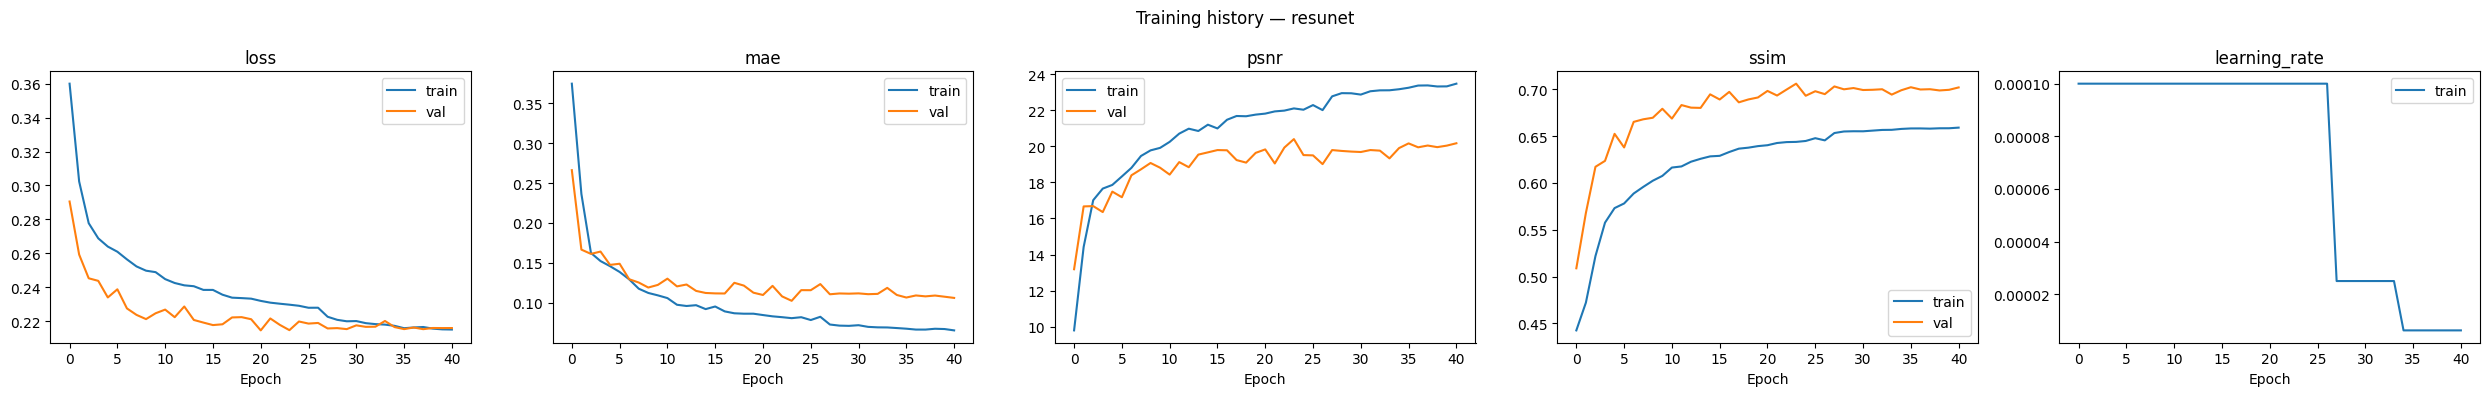

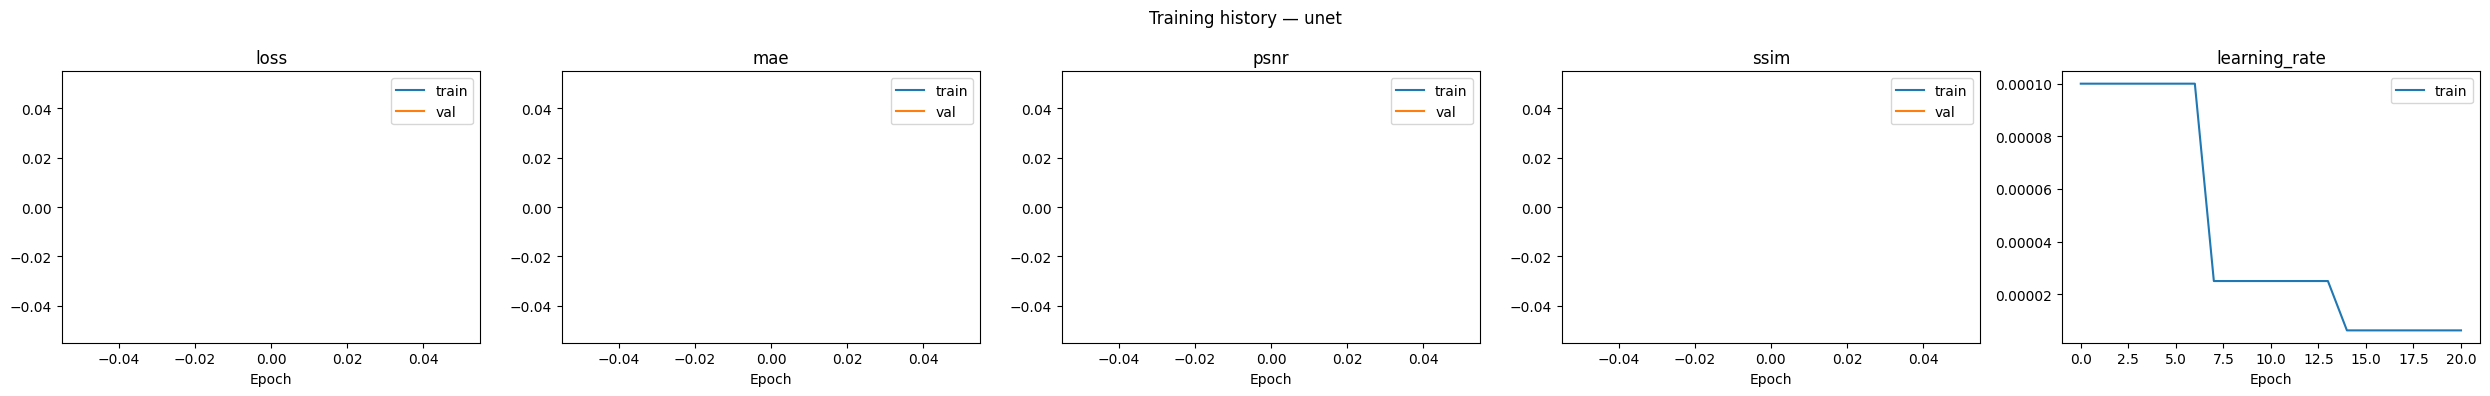

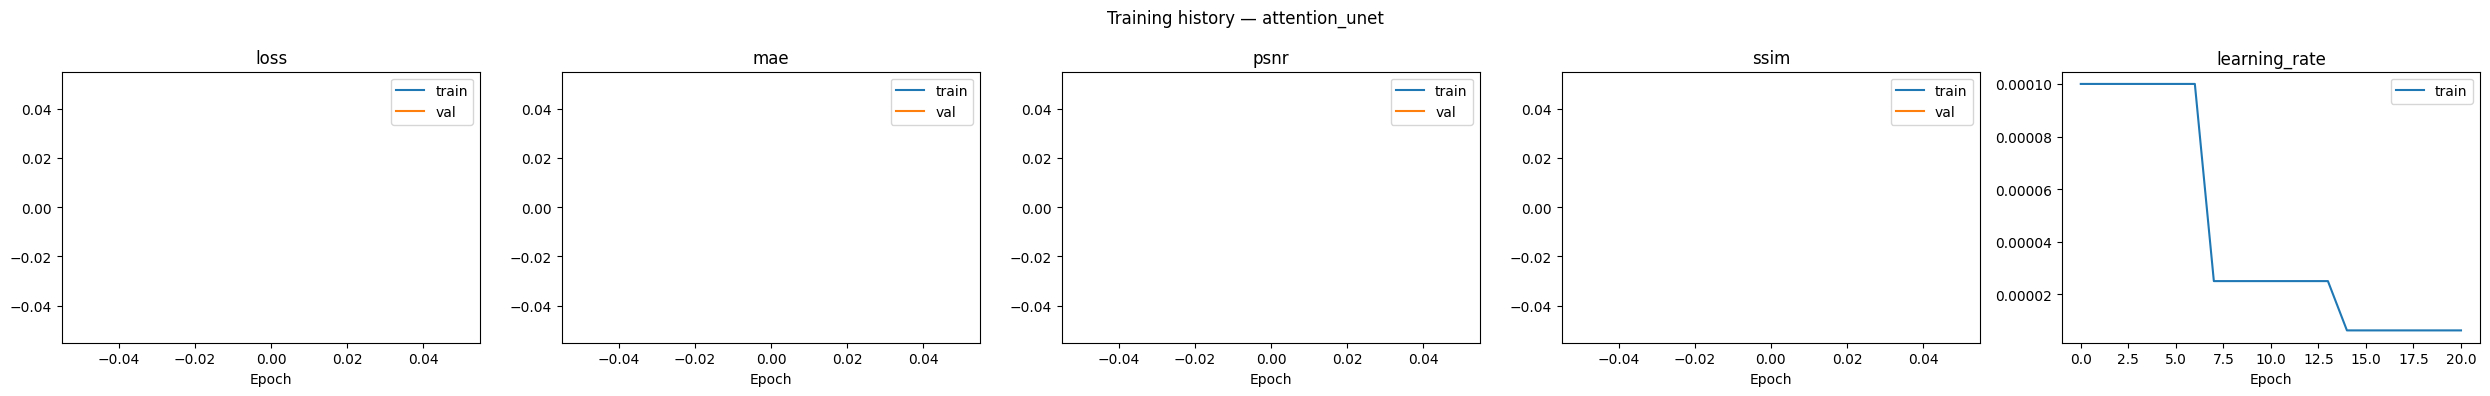

In [5]:
for arch, history in histories.items():
    plot_training_curves(history, title=f"Training history — {arch}")
    plt.show()

## 5. Summary

Checkpoints saved to `models/deterministic/<arch>/best_model.keras`. Logs written to `logs/deterministic/<arch>/` — run `tensorboard --logdir logs/` to inspect curves interactively.


In [6]:
for arch in ARCHS:
    ckpt = MODEL_DIR / arch / "best_model.keras"
    status = "found" if ckpt.exists() else "MISSING"
    print(f"{arch:<25}: {status}  ({ckpt})")

resunet                  : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/resunet/best_model.keras)
unet                     : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/unet/best_model.keras)
attention_unet           : found  (/Users/simonecaglio/Documents/GitHub/deep_layers/models/deterministic/attention_unet/best_model.keras)
